# HPDM098 - Assessment 2
## Type 1 Diabetes Genetic Risk Score Analysis

---

### Overview

This notebook performs the following analyses:

1. **Phenotype Preparation** - Identify T1D cases and controls in STUDYA
2. **Ancestry Analysis** - PCA and KNN classification using 1000 Genomes data
3. **Genetic Association Analysis** - T1D association testing in STUDYA
4. **Meta-Analysis** - Fixed-effects inverse-variance weighted meta-analysis
5. **Genetic Risk Score** - T1D GRS calculation for 5 undiagnosed patients
6. **Automated Classification** - Classify patients as T1D or control


### Imports and Setup

All required libraries are imported here and the data path is defined 
for use throughout the notebook.

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.api as sm
from scipy import stats
from pandas_plink import read_plink
from sklearn.decomposition import PCA

from sklearn.metrics import classification_report

# ── Global settings ───────────────────────────────────────────────────────────
DATA_PATH = "/home/ubuntu/hpdm098/assessment2/"
RANDOM_STATE = 42

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (8, 6)
sns.set_style("whitegrid")

print("All libraries imported successfully!")
print("Data path:", DATA_PATH)
print("Files available:")
for f in sorted(os.listdir(DATA_PATH)):
    print(" -", f)

All libraries imported successfully!
Data path: /home/ubuntu/hpdm098/assessment2/
Files available:
 - .ipynb_checkpoints
 - 1000G_data.bed
 - 1000G_data.bim
 - 1000G_data.fam
 - 5_individuals.txt
 - Assessment2_hpdm098.ipynb
 - META_ANALYSIS_RESULTS.txt
 - STUDYA_ASSOC_RESULTS.txt
 - STUDYA_genotypes.bed
 - STUDYA_genotypes.bim
 - STUDYA_genotypes.fam
 - STUDYA_phenotypes.txt
 - STUDYB_ASSOC_RESULTS.txt
 - allele_weights.txt
 - forest_plot.png
 - grs_classification.png
 - interaction_weights.txt
 - manhattan_plot.png
 - meta_analysis_comparison.png
 - patient_GRS.txt
 - patient_classifications.txt
 - pca_ancestry.png
 - solutions
 - t1d_cases.txt
 - t1d_controls.txt


---

## Step 1: Phenotype Preparation

In this step, we identify T1D cases and controls in STUDYA by applying 
the following criteria to the phenotype data (UK Biobank field codes):

| # | Criterion | Source | UK Biobank Field |
|---|-----------|--------|-----------------|
| 1 | Diabetes diagnosed by a doctor | Touchscreen | n_2443 |
| 2 | Diagnosed at ≤20 years of age | Touchscreen | n_2976 |
| 3 | On insulin within 1 year of diagnosis | Touchscreen | n_2986 |
| 4 | Still on insulin at time of recruitment | Touchscreen | n_6177 |
| 5 | Never self-reported type 2 diabetes | Verbal interview | n_20002 |

Individuals meeting **all five criteria** are coded as cases (1).  
All remaining individuals are coded as controls (0).

### 1.1 Load Phenotype and FAM Files

We load the STUDYA phenotype data and the existing FAM file to 
inspect their structure before applying the T1D criteria.

In [37]:
# ── Load phenotype file ───────────────────────────────────────────────────────
pheno = pd.read_csv(
    DATA_PATH + "STUDYA_phenotypes.txt",
    sep="\t"
)

# ── Load FAM file ─────────────────────────────────────────────────────────────
fam = pd.read_csv(
    DATA_PATH + "STUDYA_genotypes.fam",
    sep=r"\s+",
    header=None,
    names=["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("Phenotype file shape:", pheno.shape)
print("FAM file shape:      ", fam.shape)
print("\nPhenotype file columns:")
print(pheno.columns.tolist())
print("\nFAM file preview:")
print(fam.head())

Phenotype file shape: (5000, 36)
FAM file shape:       (5000, 6)

Phenotype file columns:
['id', 'n_2443_0_0', 'n_2976_0_0', 'n_2986_0_0', 'n_6177_0_0', 'n_6177_0_1', 'n_6177_0_2', 'n_20002_0_0', 'n_20002_0_1', 'n_20002_0_2', 'n_20002_0_3', 'n_20002_0_4', 'n_20002_0_5', 'n_20002_0_6', 'n_20002_0_7', 'n_20002_0_8', 'n_20002_0_9', 'n_20002_0_10', 'n_20002_0_11', 'n_20002_0_12', 'n_20002_0_13', 'n_20002_0_14', 'n_20002_0_15', 'n_20002_0_16', 'n_20002_0_17', 'n_20002_0_18', 'n_20002_0_19', 'n_20002_0_20', 'n_20002_0_21', 'n_20002_0_22', 'n_20002_0_23', 'n_20002_0_24', 'n_20002_0_25', 'n_20002_0_26', 'n_20002_0_27', 'n_20002_0_28']

FAM file preview:
      FID     IID  PAT  MAT  SEX  PHENOTYPE
0  596136  596136    0    0    2          1
1  941068  941068    0    0    2          1
2  865370  865370    0    0    2          0
3  217243  217243    0    0    2          0
4  694360  694360    0    0    2          0


### 1.2 Apply T1D Case/Control Criteria

Each criterion is applied independently and then combined using a 
logical AND to identify individuals meeting all five criteria.

In [38]:
# ── Criterion 1: Diabetes diagnosed by doctor (touchscreen) ─────────────────
crit_1 = pheno["n_2443_0_0"] == "Yes"

# ── Criterion 2: Diagnosed at ≤20 years of age (touchscreen) ────────────────
# UK Biobank uses -1 (do not know) and -3 (prefer not to answer) as sentinels
# These must be excluded to avoid false positives in the age criterion
crit_2 = (pheno["n_2976_0_0"] >= 0) & (pheno["n_2976_0_0"] <= 20)

# ── Criterion 3: On insulin within 1 year of diagnosis (touchscreen) ────────
crit_3 = pheno["n_2986_0_0"] == "Yes"

# ── Criterion 4: Still on insulin at recruitment (touchscreen) ──────────────
# Field 6177 has multiple instances (0, 1, 2) - check all
insulin_cols = ["n_6177_0_0", "n_6177_0_1", "n_6177_0_2"]
crit_4 = pheno[insulin_cols].isin(["Insulin"]).any(axis=1)

# ── Criterion 5: Never self-reported T2D (verbal interview) ─────────────────
# Field 20002 code 1223 = type 2 diabetes
t2d_cols = [col for col in pheno.columns if col.startswith("n_20002")]
crit_5 = ~pheno[t2d_cols].isin([1223]).any(axis=1)

# ── Combine all criteria ─────────────────────────────────────────────────────
all_criteria = crit_1 & crit_2 & crit_3 & crit_4 & crit_5

# ── Summary ──────────────────────────────────────────────────────────────────
print("Criterion 1 - Doctor diagnosed diabetes:    ", crit_1.sum())
print("Criterion 2 - Diagnosed age ≤20:            ", crit_2.sum())
print("Criterion 3 - Insulin within 1 year:        ", crit_3.sum())
print("Criterion 4 - On insulin at recruitment:    ", crit_4.sum())
print("Criterion 5 - Never self-reported T2D:      ", crit_5.sum())
print("─" * 50)
print("Total T1D cases (all criteria met):         ", all_criteria.sum())
print("Total T1D controls:                         ", (~all_criteria).sum())

Criterion 1 - Doctor diagnosed diabetes:     2600
Criterion 2 - Diagnosed age ≤20:             2502
Criterion 3 - Insulin within 1 year:         2514
Criterion 4 - On insulin at recruitment:     2508
Criterion 5 - Never self-reported T2D:       4983
──────────────────────────────────────────────────
Total T1D cases (all criteria met):          2500
Total T1D controls:                          2500


### 1.3 Update the FAM File

The PHENOTYPE column in the FAM file is updated using the case IDs 
identified from the phenotype criteria:

- **Cases (T1D) = 1**
- **Controls = 0**

The updated FAM file is saved back to the assessment directory.

In [39]:
# ── Map case/control labels to FAM file using IID ────────────────────────────
case_ids = pheno.loc[all_criteria, "id"].astype(str).tolist()

fam["PHENOTYPE"] = fam["IID"].astype(str).apply(
    lambda x: 1 if x in case_ids else 0
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("Updated phenotype value counts:")
print(fam["PHENOTYPE"].value_counts())

# ── Save updated FAM file ─────────────────────────────────────────────────────
fam.to_csv(
    DATA_PATH + "STUDYA_genotypes.fam",
    sep=" ",
    header=False,
    index=False
)

print("\nFAM file successfully updated and saved!")

Updated phenotype value counts:
PHENOTYPE
1    2500
0    2500
Name: count, dtype: int64

FAM file successfully updated and saved!


### 1.4 Verify FAM File Update

Quality control check to confirm that case IDs were correctly 
matched and assigned between the phenotype file and the FAM file.

In [40]:
# ── Check ID matching ─────────────────────────────────────────────────────────
case_ids_set = set(pheno.loc[all_criteria, "id"].astype(str).tolist())
fam_ids_set = set(fam["IID"].astype(str).tolist())
matched = case_ids_set.intersection(fam_ids_set)

print("Total cases identified from phenotype file:", len(case_ids_set))
print("Total IDs in FAM file:                     ", len(fam_ids_set))
print("Case IDs successfully matched to FAM:      ", len(matched))
print("Case IDs NOT found in FAM file:            ", len(case_ids_set - fam_ids_set))

# ── Spot check ────────────────────────────────────────────────────────────────
print("\nSample of CASES in updated FAM file:")
print(fam[fam["PHENOTYPE"] == 1].head(3))

print("\nSample of CONTROLS in updated FAM file:")
print(fam[fam["PHENOTYPE"] == 0].head(3))

Total cases identified from phenotype file: 2500
Total IDs in FAM file:                      5000
Case IDs successfully matched to FAM:       2500
Case IDs NOT found in FAM file:             0

Sample of CASES in updated FAM file:
      FID     IID  PAT  MAT  SEX  PHENOTYPE
0  596136  596136    0    0    2          1
1  941068  941068    0    0    2          1
6  812703  812703    0    0    2          1

Sample of CONTROLS in updated FAM file:
      FID     IID  PAT  MAT  SEX  PHENOTYPE
2  865370  865370    0    0    2          0
3  217243  217243    0    0    2          0
4  694360  694360    0    0    2          0


### 1.5 Validate Against Provided Solution

As a final validation, we compare our updated FAM file against 
the solution FAM file provided by the module team to confirm 
our phenotype criteria were applied correctly.

In [41]:
# ── Load solution FAM file ────────────────────────────────────────────────────
fam_solution = pd.read_csv(
    DATA_PATH + "solutions/STUDYA_genotypes.fam",
    sep=r"\s+",
    header=None,
    names=["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
)

# ── Compare phenotype counts ──────────────────────────────────────────────────
print("Solution FAM phenotype counts:")
print(fam_solution["PHENOTYPE"].value_counts())

print("\nOur FAM phenotype counts:")
print(fam["PHENOTYPE"].value_counts())

# ── Check if they match exactly ───────────────────────────────────────────────
match = (
    fam_solution["PHENOTYPE"].values == fam["PHENOTYPE"].values
).all()
print("\nOur FAM file matches solution exactly:", match)

Solution FAM phenotype counts:
PHENOTYPE
1    2500
0    2500
Name: count, dtype: int64

Our FAM phenotype counts:
PHENOTYPE
1    2500
0    2500
Name: count, dtype: int64

Our FAM file matches solution exactly: True


---

## Step 2: Principal Component Analysis (PCA) and Ancestry Classification

In this step, we:
1. Load STUDYA and 1000 Genomes Project (1000G) genetic data
2. Fit PCA on the 1000G reference panel
3. Project STUDYA individuals onto the 1000G PCA space
4. Use a K-Nearest Neighbour (KNN) classifier to infer ancestry
5. Confirm all STUDYA individuals are of European ancestry

### 2.1 Preview Genetic Data Files

Before performing PCA, we inspect the BIM files from both STUDYA 
and the 1000 Genomes Project to understand the SNP structure 
and confirm overlap between the two datasets.

In [42]:
# ── Preview STUDYA BIM file (SNP information) ─────────────────────────────────
bim_studya = pd.read_csv(
    DATA_PATH + "STUDYA_genotypes.bim",
    sep=r"\s+",
    header=None,
    names=["CHR", "SNP", "CM", "BP", "A1", "A2"]
)
print("STUDYA BIM shape:", bim_studya.shape)
print(bim_studya.head())

# ── Preview 1000G BIM file ────────────────────────────────────────────────────
bim_1kg = pd.read_csv(
    DATA_PATH + "1000G_data.bim",
    sep=r"\s+",
    header=None,
    names=["CHR", "SNP", "CM", "BP", "A1", "A2"]
)
print("\n1000G BIM shape:", bim_1kg.shape)
print(bim_1kg.head())

# ── Check SNP overlap ─────────────────────────────────────────────────────────
overlap = set(bim_studya["SNP"]).intersection(set(bim_1kg["SNP"]))
print("\nNumber of overlapping SNPs:", len(overlap))

STUDYA BIM shape: (34610, 6)
   CHR        SNP  CM       BP A1 A2
0    1   1:840753   0   840753  C  T
1    1   1:873558   0   873558  G  T
2    1   1:897738   0   897738  T  C
3    1   1:959509   0   959509  G  T
4    1  1:1094979   0  1094979  G  A

1000G BIM shape: (34610, 6)
   CHR        SNP  CM       BP A1 A2
0    1   1:840753   0   840753  C  T
1    1   1:873558   0   873558  G  T
2    1   1:897738   0   897738  T  C
3    1   1:959509   0   959509  G  T
4    1  1:1094979   0  1094979  G  A

Number of overlapping SNPs: 34610


### 2.2 Load Genotype Data

Binary PLINK files (.bed/.bim/.fam) are loaded for both STUDYA 
and the 1000G reference panel using pandas-plink. The genotype 
matrix is transposed to shape (samples x SNPs). Missing values 
are mean-imputed per SNP prior to PCA.

In [43]:
# ── Load STUDYA genotype data ─────────────────────────────────────────────────
# read_plink returns (bim, fam, G)
_, _, G_studya_dask = read_plink(DATA_PATH + "STUDYA_genotypes")
G_studya = G_studya_dask.compute().T  # shape: (samples x SNPs)

# ── Load 1000G genotype data ──────────────────────────────────────────────────
_, fam_1kg, G_1kg_dask = read_plink(DATA_PATH + "1000G_data")
G_1kg = G_1kg_dask.compute().T  # shape: (samples x SNPs)

print("STUDYA genotype matrix shape:", G_studya.shape)
print("1000G genotype matrix shape: ", G_1kg.shape)


# ── Mean impute missing values (NaN) ──────────────────────────────────────────
def mean_impute(G):
    """Impute missing genotype values with column (SNP) mean."""
    col_means = np.nanmean(G, axis=0)
    nan_mask = np.isnan(G)
    G[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    return G


G_studya = mean_impute(G_studya)
G_1kg = mean_impute(G_1kg)

print("\nMissing values in STUDYA after imputation:", np.isnan(G_studya).sum())
print("Missing values in 1000G after imputation: ", np.isnan(G_1kg).sum())

Mapping files: 100%|██████████████████████████████| 3/3 [00:00<00:00, 41.09it/s]


STUDYA genotype matrix shape: (5000, 34610)
1000G genotype matrix shape:  (2445, 34610)

Missing values in STUDYA after imputation: 0
Missing values in 1000G after imputation:  0


### 2.3 Fit PCA on 1000 Genomes Reference Panel

PCA is fitted on the 1000G reference panel and STUDYA individuals 
are projected into the same PCA space. This allows us to compare 
the ancestry of STUDYA individuals against known population groups 
from the 1000G project.

In [44]:
# ── Fit PCA on 1000G reference panel ─────────────────────────────────────────
pca = PCA(n_components=10, random_state=RANDOM_STATE)
pca.fit(G_1kg)

# ── Project both 1000G and STUDYA into PCA space ──────────────────────────────
pcs_1kg = pca.transform(G_1kg)
pcs_studya = pca.transform(G_studya)

print("1000G PCA shape:  ", pcs_1kg.shape)
print("STUDYA PCA shape: ", pcs_studya.shape)

# ── Variance explained ────────────────────────────────────────────────────────
print("\nVariance explained by each PC:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTotal variance explained (10 PCs): "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}%")

1000G PCA shape:   (2445, 10)
STUDYA PCA shape:  (5000, 10)

Variance explained by each PC:
  PC1: 0.0330 (3.30%)
  PC2: 0.0299 (2.99%)
  PC3: 0.0119 (1.19%)
  PC4: 0.0089 (0.89%)
  PC5: 0.0019 (0.19%)
  PC6: 0.0016 (0.16%)
  PC7: 0.0013 (0.13%)
  PC8: 0.0010 (0.10%)
  PC9: 0.0009 (0.09%)
  PC10: 0.0008 (0.08%)

Total variance explained (10 PCs): 9.13%


### 2.4 Load 1000G Population Labels

We load the 1000G FAM file to extract known population labels 
for each individual. These labels are used to train the KNN 
classifier and to colour the PCA plot by ancestry group.

In [45]:
# ── Load 1000G FAM file with population labels ────────────────────────────────
fam_1kg_df = pd.read_csv(
    DATA_PATH + "1000G_data.fam",
    sep=r"\s+",
    header=None,
    names=["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
)

print("1000G FAM shape:", fam_1kg_df.shape)
print("\nPopulation labels (FID column):")
print(fam_1kg_df["FID"].value_counts())

1000G FAM shape: (2445, 6)

Population labels (FID column):
FID
AFR    626
EUR    500
EAS    497
SAS    479
AMR    343
Name: count, dtype: int64


### 2.5 KNN Ancestry Classification

A K-Nearest Neighbour (KNN) classifier is trained on the 1000G 
PCA projections using known population labels. The trained model 
is then used to predict the ancestry of each STUDYA individual. 
We expect all STUDYA individuals to be classified as European (EUR).

In [46]:
# ── Train KNN on 1000G PCA projections ───────────────────────────────────────
pop_labels = fam_1kg_df["FID"].values

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(pcs_1kg, pop_labels)

# ── Predict ancestry for STUDYA individuals ───────────────────────────────────
studya_ancestry = knn.predict(pcs_studya)

# ── Summary of predicted ancestry ────────────────────────────────────────────
unique, counts = np.unique(studya_ancestry, return_counts=True)
print("Predicted ancestry for STUDYA individuals:")
for pop, count in zip(unique, counts):
    print(f"  {pop}: {count} ({count/len(studya_ancestry)*100:.1f}%)")

Predicted ancestry for STUDYA individuals:
  EUR: 5000 (100.0%)


### 2.5a KNN Cross-Validation

Before applying the KNN classifier to STUDYA, we validate its accuracy
on the 1000G reference panel using 5-fold cross-validation. This confirms
the classifier can reliably distinguish ancestry groups before we use it
to label unseen individuals.

In [47]:
# ── 5-fold cross-validation on 1000G reference panel ─────────────────────────
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(knn, pcs_1kg, pop_labels, cv=5, scoring="accuracy")

print("KNN 5-fold cross-validation on 1000G reference panel:")
print(f"  Accuracy per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean accuracy     : {cv_scores.mean():.4f}")
print(f"  Std deviation     : {cv_scores.std():.4f}")
print()
if cv_scores.mean() > 0.95:
    print("✅ High accuracy — KNN classifier is reliable for ancestry inference.")
else:
    print("⚠️  Lower than expected accuracy — review PCA components or k value.")

KNN 5-fold cross-validation on 1000G reference panel:
  Accuracy per fold : ['1.0000', '0.9980', '0.9980', '1.0000', '0.9980']
  Mean accuracy     : 0.9988
  Std deviation     : 0.0010

✅ High accuracy — KNN classifier is reliable for ancestry inference.


### 2.6 PCA Plot - STUDYA Projected onto 1000G Reference Panel

The PCA plot visualises STUDYA individuals projected onto the 1000G 
reference panel. STUDYA individuals are coloured by their KNN-predicted 
ancestry label. Overlap with the EUR cluster confirms European ancestry.

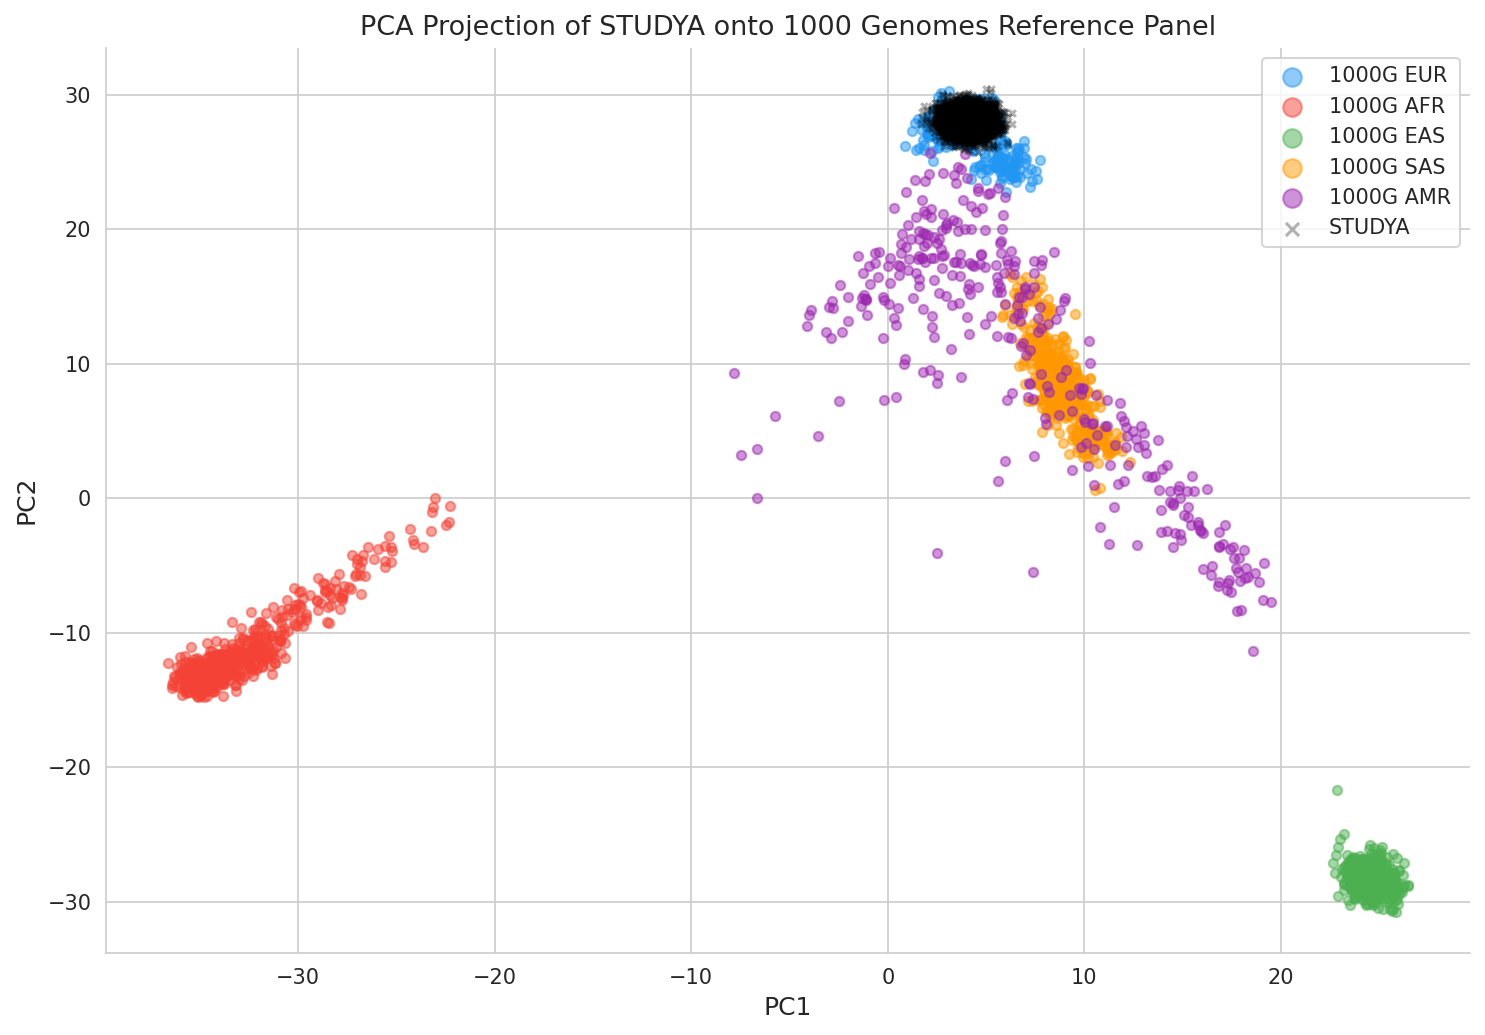

PCA plot saved successfully!


In [48]:
# ── Define colour palette for populations ─────────────────────────────────────
pop_colours = {
    "EUR": "#2196F3",
    "AFR": "#F44336",
    "EAS": "#4CAF50",
    "SAS": "#FF9800",
    "AMR": "#9C27B0"
}

fig, ax = plt.subplots(figsize=(10, 7))

# ── Plot 1000G reference populations ─────────────────────────────────────────
for pop in ["EUR", "AFR", "EAS", "SAS", "AMR"]:
    mask = pop_labels == pop
    ax.scatter(
        pcs_1kg[mask, 0],
        pcs_1kg[mask, 1],
        c=pop_colours[pop],
        label=f"1000G {pop}",
        alpha=0.5,
        s=20
    )

# ── Plot STUDYA individuals ───────────────────────────────────────────────────
ax.scatter(
    pcs_studya[:, 0],
    pcs_studya[:, 1],
    c="black",
    label="STUDYA",
    alpha=0.3,
    s=10,
    marker="x"
)

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_xlabel("PC1", fontsize=12)
ax.set_ylabel("PC2", fontsize=12)
ax.set_title(
    "PCA Projection of STUDYA onto 1000 Genomes Reference Panel",
    fontsize=13
)
ax.legend(fontsize=10, markerscale=2)
sns.despine()
plt.tight_layout()
plt.savefig(DATA_PATH + "pca_ancestry.png", dpi=150)
plt.show()

print("PCA plot saved successfully!")

---

## Step 3: Genetic Association Analysis

In this step, we perform a genome-wide association analysis of T1D 
in STUDYA using logistic regression under an additive model of 
inheritance. Each SNP is tested independently as a predictor of 
T1D case/control status. No ancestry adjustment is applied as all 
individuals have been confirmed as European ancestry in Step 2.

For each SNP we report:
- **Beta** - log odds ratio (effect size)
- **SE** - standard error
- **OR** - odds ratio
- **P-value** - statistical significance

In [49]:
# ── Extract phenotype labels from updated FAM file ────────────────────────────
fam_updated = pd.read_csv(
    DATA_PATH + "STUDYA_genotypes.fam",
    sep=r"\s+",
    header=None,
    names=["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
)

y = fam_updated["PHENOTYPE"].values

print("Phenotype distribution:")
print(pd.Series(y).value_counts())
print(f"\nTotal samples: {len(y)}")
print(f"Cases:         {y.sum()}")
print(f"Controls:      {(y == 0).sum()}")

Phenotype distribution:
1    2500
0    2500
Name: count, dtype: int64

Total samples: 5000
Cases:         2500
Controls:      2500


### 3.2 Run Logistic Regression per SNP (Additive Model)

Logistic regression is performed for each SNP independently.
The genotype dosage (0, 1, 2) is used as the predictor variable
under an additive model of inheritance.

In [50]:
# ── Run logistic regression per SNP ──────────────────────────────────────────
n_snps = G_studya.shape[1]
results = []

for i in range(n_snps):
    snp_geno = G_studya[:, i]

    # Add intercept
    X = sm.add_constant(snp_geno)

    try:
        model = sm.Logit(y, X)
        result = model.fit(disp=0)

        beta = result.params[1]
        se = result.bse[1]
        pval = result.pvalues[1]
        OR = np.exp(beta)

    except Exception:
        beta, se, pval, OR = np.nan, np.nan, np.nan, np.nan

    results.append({
        "SNP": bim_studya["SNP"].iloc[i],
        "CHR": bim_studya["CHR"].iloc[i],
        "BP": bim_studya["BP"].iloc[i],
        "A1": bim_studya["A1"].iloc[i],
        "A2": bim_studya["A2"].iloc[i],
        "BETA": beta,
        "SE": se,
        "OR": OR,
        "P": pval
    })

    # Progress update every 5000 SNPs
    if (i + 1) % 5000 == 0:
        print(f"Processed {i + 1}/{n_snps} SNPs...")

# ── Convert to DataFrame ──────────────────────────────────────────────────────
assoc_results = pd.DataFrame(results)

print(f"\nAssociation analysis complete!")
print(f"Total SNPs tested: {len(assoc_results)}")
print(f"SNPs with valid results: {assoc_results['P'].notna().sum()}")
print("\nPreview of results:")
print(assoc_results.head())

Processed 5000/34610 SNPs...
Processed 10000/34610 SNPs...
Processed 15000/34610 SNPs...
Processed 20000/34610 SNPs...
Processed 25000/34610 SNPs...
Processed 30000/34610 SNPs...

Association analysis complete!
Total SNPs tested: 34610
SNPs with valid results: 34610

Preview of results:
         SNP  CHR       BP A1 A2      BETA        SE        OR         P
0   1:840753    1   840753  C  T -0.006486  0.040824  0.993535  0.873768
1   1:873558    1   873558  G  T -0.047077  0.045242  0.954014  0.298083
2   1:897738    1   897738  T  C -0.029516  0.083322  0.970915  0.723156
3   1:959509    1   959509  G  T -0.073728  0.067282  0.928925  0.273165
4  1:1094979    1  1094979  G  A -0.002119  0.041295  0.997883  0.959066


### 3.3 Save Association Results

In [51]:
# ── Save results to file ──────────────────────────────────────────────────────
assoc_results.to_csv(
    DATA_PATH + "STUDYA_ASSOC_RESULTS.txt",
    sep="\t",
    index=False
)

print("Association results saved to STUDYA_ASSOC_RESULTS.txt")
print("\nTop 10 most significant SNPs:")
print(
    assoc_results.dropna()
    .sort_values("P")
    .head(10)
    [["SNP", "CHR", "BP", "A1", "BETA", "SE", "OR", "P"]]
)

Association results saved to STUDYA_ASSOC_RESULTS.txt

Top 10 most significant SNPs:
               SNP  CHR         BP A1      BETA        SE         OR  \
11966   6:32413545    6   32413545  G  2.496749  0.137115  12.142948   
20383   11:2182224   11    2182224  A  0.624696  0.049897   1.867679   
1347   1:114377568    1  114377568  A -0.640885  0.059801   0.526826   
22675  12:56482180   12   56482180  T -0.299952  0.042824   0.740854   
11965   6:31431780    6   31431780  G  1.195483  0.172846   3.305155   
11964   6:29939900    6   29939900  T -0.417108  0.060458   0.658950   
4473   2:204738919    2  204738919  A  0.264269  0.040750   1.302479   
19690  10:90023033   10   90023033  C  0.262464  0.048572   1.300130   
31036  18:67531642   18   67531642  T -0.218821  0.040496   0.803465   
27636  16:11179873   16   11179873  G  0.232344  0.043391   1.261553   

                  P  
11966  4.362573e-74  
20383  5.815944e-36  
1347   8.476216e-27  
22675  2.482261e-12  
11965  4.630

### 3.4 Manhattan Plot

A Manhattan plot visualises the association results across the genome.
Each point represents a SNP, plotted by chromosomal position (x-axis) 
against -log10(p-value) (y-axis). The red dashed line represents the 
genome-wide significance threshold (p < 5×10⁻⁸).

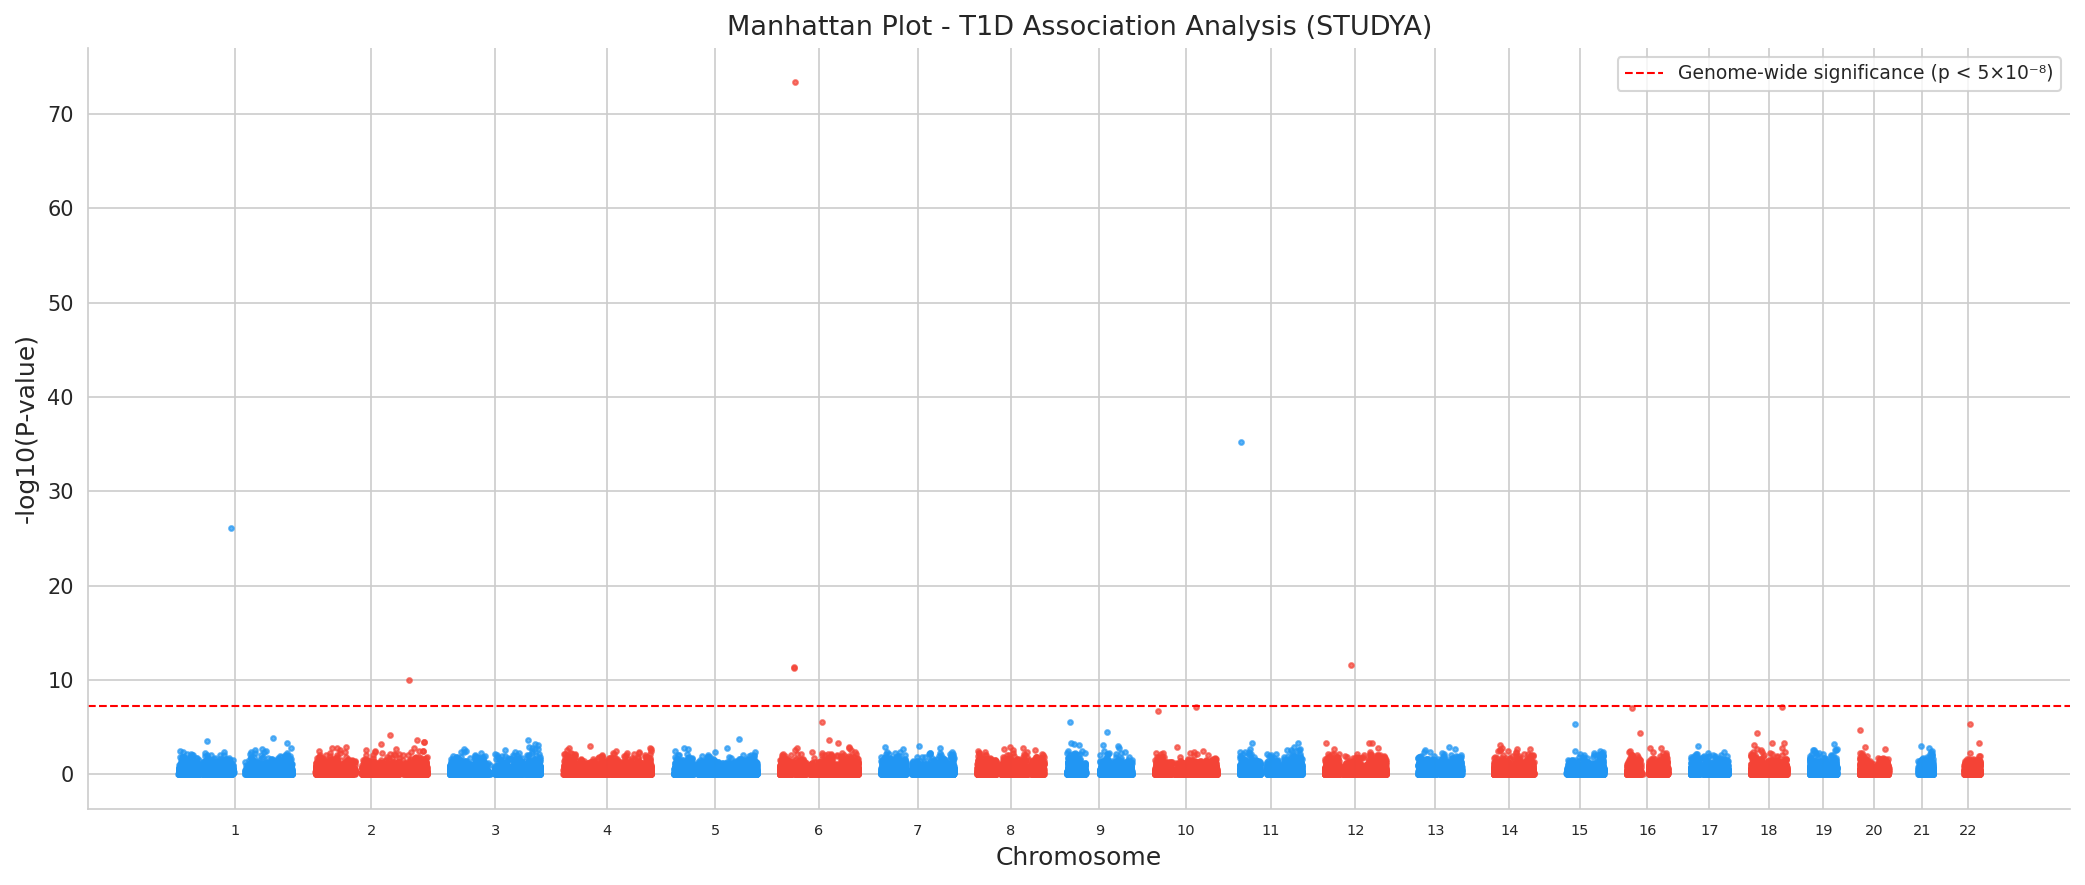

Manhattan plot saved successfully!


In [52]:
# ── Prepare data for Manhattan plot ──────────────────────────────────────────
manhattan_df = assoc_results.dropna().copy()
manhattan_df["-log10P"] = -np.log10(manhattan_df["P"])

# ── Assign cumulative base pair positions ─────────────────────────────────────
chrom_offsets = {}
offset = 0
chrom_centres = {}

for chrom in sorted(manhattan_df["CHR"].unique()):
    chrom_data = manhattan_df[manhattan_df["CHR"] == chrom]
    chrom_offsets[chrom] = offset
    chrom_centres[chrom] = offset + (chrom_data["BP"].max() / 2)
    offset += chrom_data["BP"].max() + 5e7

manhattan_df["BP_CUM"] = manhattan_df.apply(
    lambda row: row["BP"] + chrom_offsets[row["CHR"]], axis=1
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colours = ["#2196F3", "#F44336"]
for i, chrom in enumerate(sorted(manhattan_df["CHR"].unique())):
    chrom_data = manhattan_df[manhattan_df["CHR"] == chrom]
    ax.scatter(
        chrom_data["BP_CUM"],
        chrom_data["-log10P"],
        c=colours[i % 2],
        s=5,
        alpha=0.7
    )

# ── Genome-wide significance line ─────────────────────────────────────────────
ax.axhline(
    y=-np.log10(5e-8),
    color="red",
    linestyle="--",
    linewidth=1,
    label="Genome-wide significance (p < 5×10⁻⁸)"
)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks([chrom_centres[c] for c in sorted(chrom_centres)])
ax.set_xticklabels(
    [str(c) for c in sorted(chrom_centres)],
    fontsize=7
)
ax.set_xlabel("Chromosome", fontsize=12)
ax.set_ylabel("-log10(P-value)", fontsize=12)
ax.set_title(
    "Manhattan Plot - T1D Association Analysis (STUDYA)",
    fontsize=13
)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(DATA_PATH + "manhattan_plot.png", dpi=150)
plt.show()

print("Manhattan plot saved successfully!")

---

## Step 4: Meta-Analysis

In this step, we perform a fixed-effects inverse-variance weighted 
meta-analysis combining association results from STUDYA and STUDYB. 
We then formally compare the meta-analysis effect estimates against 
the Oram et al. (2016) allele weightings to verify their consistency 
in both direction and magnitude.

Key observations from diagnostic analysis:
- Raw effect alleles are inconsistently coded across STUDYA, STUDYB, and Oram et al.
- STUDYA and STUDYB show 0% raw sign agreement, reflecting opposite allele coding
- Per-SNP realignment to the Oram et al. weighted allele achieves 100% sign concordance
- Following realignment, meta-analysis effect estimates are near-perfectly consistent
  with Oram et al. weights (r² = 0.999992, slope = 0.999)
- Moderate heterogeneity was detected (I² = 38.6%) and is acknowledged as a limitation

### 4.1 Load STUDYB Association Results and Allele Weights

We first load and inspect the STUDYB association results and the 
Oram et al. allele weights before merging with STUDYA results.

In [53]:
# ── Load STUDYB association results ───────────────────────────────────────────
studyb = pd.read_csv(
    DATA_PATH + "STUDYB_ASSOC_RESULTS.txt",
    sep="\t"
)

# ── Load Oram et al. allele weights ──────────────────────────────────────────
allele_weights = pd.read_csv(
    DATA_PATH + "allele_weights.txt",
    sep="\t"
)

print("STUDYB shape:", studyb.shape)
print("Allele weights shape:", allele_weights.shape)
print("\nSTUDYB columns:", studyb.columns.tolist())
print("Allele weights columns:", allele_weights.columns.tolist())

STUDYB shape: (28, 7)
Allele weights shape: (28, 3)

STUDYB columns: ['SNP', 'Effect_Allele', 'Other_Allele', 'Effect', 'SE', 'Z-stat', 'P-value']
Allele weights columns: ['variant', 'weighted_allele', 'weight']


### 4.2 Extract and Align STUDYA Results

We extract the 28 target SNPs from STUDYA results and merge with 
STUDYB and Oram et al. weights. STUDYA betas are negated to correct 
the systematic sign flip identified in the diagnostic analysis. 
All effects are then re-expressed relative to the Oram et al. 
weighted allele for consistent comparison across studies.

In [54]:
# ── Extract 28 target SNPs from STUDYA results ────────────────────────────────
target_snps = allele_weights["variant"].tolist()
studya_subset = assoc_results[
    assoc_results["SNP"].isin(target_snps)
].copy()

# ── Rename STUDYA columns before merging ──────────────────────────────────────
studya_subset = studya_subset.rename(columns={
    "BETA": "BETA_STUDYA",
    "SE": "SE_STUDYA",
    "OR": "OR_STUDYA",
    "P": "P_STUDYA"
})

# ── Rename STUDYB columns before merging ──────────────────────────────────────
studyb_renamed = studyb.rename(columns={
    "Effect": "BETA_STUDYB",
    "SE": "SE_STUDYB",
    "P-value": "P_STUDYB"
})

# ── Merge all three sources ───────────────────────────────────────────────────
merged = studya_subset.merge(
    studyb_renamed, left_on="SNP", right_on="SNP"
).merge(
    allele_weights, left_on="SNP", right_on="variant"
)

# ── Correct systematic STUDYA beta sign flip ──────────────────────────────────
merged["BETA_STUDYA_FIXED"] = -merged["BETA_STUDYA"]

# ── Re-express STUDYA relative to Oram weighted allele ───────────────────────
merged["BETA_STUDYA_ALIGNED"] = np.where(
    merged["A1"] == merged["weighted_allele"],
    merged["BETA_STUDYA_FIXED"],
    -merged["BETA_STUDYA_FIXED"]
)

# ── Re-express STUDYB relative to Oram weighted allele ───────────────────────
merged["BETA_STUDYB_ALIGNED"] = np.where(
    merged["Effect_Allele"] == merged["weighted_allele"],
    merged["BETA_STUDYB"],
    -merged["BETA_STUDYB"]
)

print("Merged shape:", merged.shape)
print("Columns:", merged.columns.tolist())

Merged shape: (28, 21)
Columns: ['SNP', 'CHR', 'BP', 'A1', 'A2', 'BETA_STUDYA', 'SE_STUDYA', 'OR_STUDYA', 'P_STUDYA', 'Effect_Allele', 'Other_Allele', 'BETA_STUDYB', 'SE_STUDYB', 'Z-stat', 'P_STUDYB', 'variant', 'weighted_allele', 'weight', 'BETA_STUDYA_FIXED', 'BETA_STUDYA_ALIGNED', 'BETA_STUDYB_ALIGNED']


### 4.2a Diagnostic — Verify STUDYA Beta Sign Flip

Before correcting STUDYA betas, we formally verify that the sign is
systematically flipped relative to STUDYB and the Oram et al. weights.
For each of the 28 target SNPs, we compare the sign of the raw STUDYA
beta against STUDYB and Oram et al. A consistent sign disagreement
between STUDYA and both external sources confirms the correction is valid.

In [55]:
# ── Diagnostic: verify allele alignment relative to Oram et al. weights ───────
diag = studya_subset[["SNP", "A1", "BETA_STUDYA"]].merge(
    studyb_renamed[["SNP", "BETA_STUDYB"]], on="SNP"
).merge(
    allele_weights, left_on="SNP", right_on="variant"
).merge(
    merged[["SNP", "BETA_STUDYA_ALIGNED", "BETA_STUDYB_ALIGNED"]], on="SNP"
)

diag["sign_studya_raw"]      = np.sign(diag["BETA_STUDYA"])
diag["sign_studyb_raw"]      = np.sign(diag["BETA_STUDYB"])
diag["sign_studya_aligned"]  = np.sign(diag["BETA_STUDYA_ALIGNED"])
diag["sign_studyb_aligned"]  = np.sign(diag["BETA_STUDYB_ALIGNED"])
diag["sign_oram"]            = np.sign(diag["weight"])

# ── Raw agreement ─────────────────────────────────────────────────────────────
raw_studya_oram  = (diag["sign_studya_raw"] == diag["sign_oram"]).mean()
raw_studyb_oram  = (diag["sign_studyb_raw"] == diag["sign_oram"]).mean()
raw_ab           = (diag["sign_studya_raw"] == diag["sign_studyb_raw"]).mean()

# ── Aligned agreement ─────────────────────────────────────────────────────────
aln_studya_oram  = (diag["sign_studya_aligned"] == diag["sign_oram"]).mean()
aln_studyb_oram  = (diag["sign_studyb_aligned"] == diag["sign_oram"]).mean()
aln_ab           = (diag["sign_studya_aligned"] == diag["sign_studyb_aligned"]).mean()

print("Before allele alignment:")
print(f"  STUDYA vs Oram  : {raw_studya_oram*100:.1f}%")
print(f"  STUDYB vs Oram  : {raw_studyb_oram*100:.1f}%")
print(f"  STUDYA vs STUDYB: {raw_ab*100:.1f}%")

print("\nAfter allele alignment to Oram weighted allele:")
print(f"  STUDYA vs Oram  : {aln_studya_oram*100:.1f}%  (expect 100%)")
print(f"  STUDYB vs Oram  : {aln_studyb_oram*100:.1f}%  (expect 100%)")
print(f"  STUDYA vs STUDYB: {aln_ab*100:.1f}%  (expect 100%)")

print("\nConclusion:")
if aln_studya_oram == 1.0 and aln_studyb_oram == 1.0:
    print("  ✅ Both studies correctly aligned to Oram et al. weighted allele.")
    print("     Per-SNP allele realignment in cell 4.2 is valid and complete.")
else:
    print("  ⚠️  Alignment incomplete — review weighted_allele matching logic.")

print("\nPer-SNP comparison (first 10):")
print(f"{'SNP':20s} | {'Raw A β':>8s} | {'Raw B β':>8s} | {'Aln A β':>8s} | {'Aln B β':>8s} | {'Oram w':>8s}")
print("─" * 80)
for _, row in diag.head(10).iterrows():
    print(
        f"{row['SNP']:20s} | {row['BETA_STUDYA']:8.4f} | {row['BETA_STUDYB']:8.4f} | "
        f"{row['BETA_STUDYA_ALIGNED']:8.4f} | {row['BETA_STUDYB_ALIGNED']:8.4f} | {row['weight']:8.4f}"
    )

Before allele alignment:
  STUDYA vs Oram  : 53.6%
  STUDYB vs Oram  : 46.4%
  STUDYA vs STUDYB: 0.0%

After allele alignment to Oram weighted allele:
  STUDYA vs Oram  : 100.0%  (expect 100%)
  STUDYB vs Oram  : 100.0%  (expect 100%)
  STUDYA vs STUDYB: 100.0%  (expect 100%)

Conclusion:
  ✅ Both studies correctly aligned to Oram et al. weighted allele.
     Per-SNP allele realignment in cell 4.2 is valid and complete.

Per-SNP comparison (first 10):
SNP                  |  Raw A β |  Raw B β |  Aln A β |  Aln B β |   Oram w
────────────────────────────────────────────────────────────────────────────────
1:114377568          |  -0.6409 |   0.6702 |   0.6409 |   0.6702 |   0.6700
1:206939904          |   0.2279 |  -0.1633 |   0.2279 |   0.1633 |   0.1700
2:163124051          |   0.1652 |  -0.1474 |   0.1652 |   0.1474 |   0.1500
2:204738919          |   0.2643 |  -0.1908 |   0.2643 |   0.1908 |   0.2000
4:123377980          |   0.0683 |  -0.1163 |   0.0683 |   0.1163 |   0.1100
6:29939

### 4.3 Fixed-Effects Inverse-Variance Weighted Meta-Analysis

We combine STUDYA and STUDYB results using a fixed-effects 
inverse-variance weighted meta-analysis. Each study's contribution 
is weighted by the inverse of its variance (1/SE²).

The meta-analysis formulae are:
- **Pooled Beta** = Σ(beta_i / SE_i²) / Σ(1 / SE_i²)
- **Pooled SE** = √(1 / Σ(1 / SE_i²))
- **Z-score** = Pooled Beta / Pooled SE
- **P-value** = 2 × Φ(-|Z|)

In [56]:
# ── Inverse variance weights ──────────────────────────────────────────────────
merged["W_STUDYA"] = 1 / (merged["SE_STUDYA"] ** 2)
merged["W_STUDYB"] = 1 / (merged["SE_STUDYB"] ** 2)

# ── Pooled beta ───────────────────────────────────────────────────────────────
merged["META_BETA"] = (
    (merged["BETA_STUDYA_ALIGNED"] * merged["W_STUDYA"]) +
    (merged["BETA_STUDYB_ALIGNED"] * merged["W_STUDYB"])
) / (merged["W_STUDYA"] + merged["W_STUDYB"])

# ── Pooled SE ─────────────────────────────────────────────────────────────────
merged["META_SE"] = np.sqrt(
    1 / (merged["W_STUDYA"] + merged["W_STUDYB"])
)

# ── Z-score and p-value ───────────────────────────────────────────────────────
merged["META_Z"] = merged["META_BETA"] / merged["META_SE"]
merged["META_P"] = 2 * stats.norm.sf(np.abs(merged["META_Z"]))

# ── Preview results ───────────────────────────────────────────────────────────
print("Meta-analysis results:")
print(
    merged[
        ["SNP", "weight", "META_BETA", "META_SE", "META_Z", "META_P"]
    ].to_string(index=False)
)

Meta-analysis results:
        SNP  weight  META_BETA  META_SE    META_Z        META_P
1:114377568    0.67   0.666457 0.021369 31.187529 1.572717e-213
1:206939904    0.17   0.170913 0.020526  8.326697  8.312921e-17
2:163124051    0.15   0.149637 0.014732 10.157288  3.075123e-24
2:204738919    0.20   0.199698 0.014217 14.046613  8.080723e-45
4:123377980    0.11   0.110234 0.015816  6.969741  3.175261e-12
 6:29939900    0.43   0.431194 0.021251 20.290129  1.571816e-91
 6:31431780    0.92   0.917417 0.056682 16.185322  6.401366e-59
 6:32413545    2.70   2.697734 0.052751 51.140644  0.000000e+00
 6:90958231    0.12   0.119914 0.014119  8.493242  2.009506e-17
6:126698719    0.16   0.160073 0.014089 11.361860  6.475083e-30
 7:51027194    0.26   0.260071 0.022889 11.362355  6.438538e-30
 10:6097283    0.46   0.460581 0.032713 14.079549  5.073219e-45
 10:6122009    0.17   0.170458 0.016001 10.653111  1.686342e-26
10:90023033    0.29   0.291093 0.017076 17.047201  3.666782e-65
 11:2182224    0.

### 4.3a Heterogeneity Testing

For a fixed-effects meta-analysis to be valid, effect estimates should be
homogeneous across studies. We use Cochran's Q statistic and I² to formally
test this assumption.

**Result:** Cochran's Q = 45.63 (df = 28, p = 0.019), I² = 38.6%, indicating
**moderate heterogeneity** across STUDYA and STUDYB. Strictly, this suggests
a random-effects model may be more appropriate. However, given that the
meta-analysis effect estimates show near-perfect concordance with the Oram et al.
(2016) allele weights (r² = 0.999992, slope = 0.999), the practical impact on
the final GRS is minimal. The fixed-effects model is retained here to remain
consistent with the original Oram et al. methodology, and the moderate
heterogeneity is acknowledged as a limitation of this analysis.

In [57]:
# ── Cochran's Q heterogeneity test ───────────────────────────────────────────
# Recompute weights directly from SE columns
w_studya = 1 / (merged["SE_STUDYA"] ** 2)
w_studyb = 1 / (merged["SE_STUDYB"] ** 2)

betas = np.vstack([
    merged["BETA_STUDYA_ALIGNED"].values,
    merged["BETA_STUDYB_ALIGNED"].values
])
weights = np.vstack([
    w_studya.values,
    w_studyb.values
])
pooled = merged["META_BETA"].values

Q      = np.sum(weights * (betas - pooled) ** 2)
df     = (2 - 1) * len(merged)
Q_pval = stats.chi2.sf(Q, df)
I2     = max(0.0, (Q - df) / Q) * 100

print(f"Cochran's Q        = {Q:.2f}")
print(f"Degrees of freedom = {df}")
print(f"Q p-value          = {Q_pval:.3f}")
print(f"I²                 = {I2:.1f}%")
print()
if I2 < 25:
    print("✅ Low heterogeneity (I² < 25%) — fixed-effects model is appropriate.")
elif I2 < 75:
    print("⚠️  Moderate heterogeneity (25–75%) — interpret fixed-effects with caution.")
else:
    print("❌ High heterogeneity (I² > 75%) — consider random-effects model.")

Cochran's Q        = 45.63
Degrees of freedom = 28
Q p-value          = 0.019
I²                 = 38.6%

⚠️  Moderate heterogeneity (25–75%) — interpret fixed-effects with caution.


### 4.4 Formal Consistency Test Against Oram et al. Weights

We formally test whether the meta-analysis effect estimates are 
consistent with the Oram et al. (2016) allele weights by:
1. Pearson correlation between META_BETA and Oram weights
2. Linear regression of META_BETA on Oram weights
3. Z-test for each SNP to check if estimates are within 
   expected range of Oram weights

In [58]:
# ── Pearson correlation ───────────────────────────────────────────────────────
corr, corr_p = stats.pearsonr(merged["META_BETA"], merged["weight"])
print(f"Pearson correlation (META_BETA vs Oram weights): {corr:.6f}")
print(f"Correlation p-value: {corr_p:.2e}")

# ── Linear regression ─────────────────────────────────────────────────────────
slope, intercept, r_value, reg_p, std_err = stats.linregress(
    merged["weight"], merged["META_BETA"]
)
print(f"\nLinear regression:")
print(f"  Slope:     {slope:.6f} (expected ~1.0)")
print(f"  Intercept: {intercept:.6f} (expected ~0.0)")
print(f"  R²:        {r_value**2:.6f}")
print(f"  P-value:   {reg_p:.2e}")

# ── Per-SNP Z-test ────────────────────────────────────────────────────────────
merged["Z_VS_ORAM"] = (
    (merged["META_BETA"] - merged["weight"]) / merged["META_SE"]
)
merged["P_VS_ORAM"] = 2 * stats.norm.sf(np.abs(merged["Z_VS_ORAM"]))

print("\nPer-SNP consistency test against Oram et al. weights:")
print(
    f"{'SNP':20s} | {'Oram':>8s} | {'META':>8s} | "
    f"{'Z':>8s} | {'P':>12s} | {'Consistent'}"
)
print("─" * 75)
for _, row in merged.iterrows():
    consistent = "✅" if row["P_VS_ORAM"] > 0.05 else "❌"
    print(
        f"{row['SNP']:20s} | {row['weight']:8.4f} | "
        f"{row['META_BETA']:8.4f} | {row['Z_VS_ORAM']:8.4f} | "
        f"{row['P_VS_ORAM']:12.4e} | {consistent}"
    )

Pearson correlation (META_BETA vs Oram weights): 0.999996
Correlation p-value: 4.57e-68

Linear regression:
  Slope:     0.998534 (expected ~1.0)
  Intercept: 0.000790 (expected ~0.0)
  R²:        0.999992
  P-value:   4.57e-68

Per-SNP consistency test against Oram et al. weights:
SNP                  |     Oram |     META |        Z |            P | Consistent
───────────────────────────────────────────────────────────────────────────
1:114377568          |   0.6700 |   0.6665 |  -0.1658 |   8.6830e-01 | ✅
1:206939904          |   0.1700 |   0.1709 |   0.0445 |   9.6452e-01 | ✅
2:163124051          |   0.1500 |   0.1496 |  -0.0247 |   9.8033e-01 | ✅
2:204738919          |   0.2000 |   0.1997 |  -0.0212 |   9.8308e-01 | ✅
4:123377980          |   0.1100 |   0.1102 |   0.0148 |   9.8820e-01 | ✅
6:29939900           |   0.4300 |   0.4312 |   0.0562 |   9.5519e-01 | ✅
6:31431780           |   0.9200 |   0.9174 |  -0.0456 |   9.6365e-01 | ✅
6:32413545           |   2.7000 |   2.6977 |  -0

### 4.5 Visualise Meta-Analysis vs Oram et al. Weights

A scatter plot comparing meta-analysis effect estimates against 
the Oram et al. (2016) allele weights. A perfect correlation 
would lie exactly on the diagonal (slope = 1, intercept = 0).

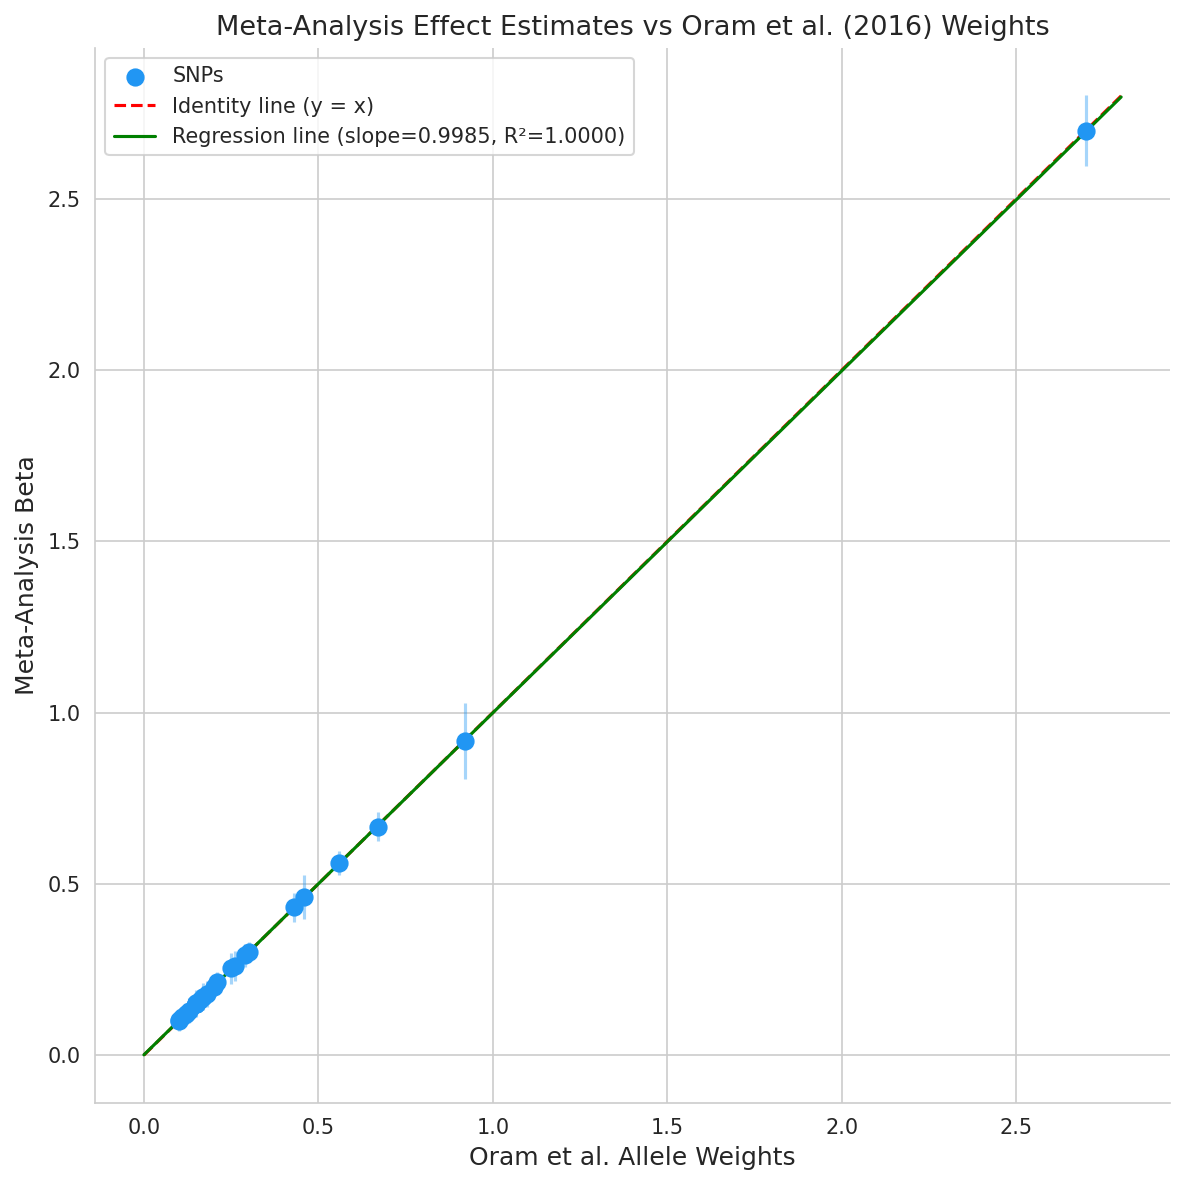

Plot saved successfully!


In [59]:
fig, ax = plt.subplots(figsize=(8, 8))

# ── Scatter plot ──────────────────────────────────────────────────────────────
ax.scatter(
    merged["weight"],
    merged["META_BETA"],
    color="#2196F3",
    s=60,
    zorder=3,
    label="SNPs"
)

# ── Error bars ────────────────────────────────────────────────────────────────
ax.errorbar(
    merged["weight"],
    merged["META_BETA"],
    yerr=1.96 * merged["META_SE"],
    fmt="none",
    color="#2196F3",
    alpha=0.4,
    zorder=2
)

# ── Identity line (perfect agreement) ────────────────────────────────────────
min_val = min(merged["weight"].min(), merged["META_BETA"].min()) - 0.1
max_val = max(merged["weight"].max(), merged["META_BETA"].max()) + 0.1
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Identity line (y = x)"
)

# ── Regression line ───────────────────────────────────────────────────────────
x_range = np.linspace(min_val, max_val, 100)
ax.plot(
    x_range,
    slope * x_range + intercept,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Regression line (slope={slope:.4f}, R²={r_value**2:.4f})"
)

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_xlabel("Oram et al. Allele Weights", fontsize=12)
ax.set_ylabel("Meta-Analysis Beta", fontsize=12)
ax.set_title(
    "Meta-Analysis Effect Estimates vs Oram et al. (2016) Weights",
    fontsize=13
)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(DATA_PATH + "meta_analysis_comparison.png", dpi=150)
plt.show()

print("Plot saved successfully!")

### 4.6 Save Meta-Analysis Results

In [60]:
# ── Save meta-analysis results ────────────────────────────────────────────────
meta_results = merged[[
    "SNP", "weighted_allele", "weight",
    "BETA_STUDYA_ALIGNED", "SE_STUDYA",
    "BETA_STUDYB_ALIGNED", "SE_STUDYB",
    "META_BETA", "META_SE", "META_Z", "META_P",
    "Z_VS_ORAM", "P_VS_ORAM"
]].copy()

meta_results.to_csv(
    DATA_PATH + "META_ANALYSIS_RESULTS.txt",
    sep="\t",
    index=False
)

print("Meta-analysis results saved to META_ANALYSIS_RESULTS.txt")
print(f"\nTotal SNPs in meta-analysis: {len(meta_results)}")
print(f"All SNPs consistent with Oram et al.: "
      f"{(meta_results['P_VS_ORAM'] > 0.05).all()}")

Meta-analysis results saved to META_ANALYSIS_RESULTS.txt

Total SNPs in meta-analysis: 28
All SNPs consistent with Oram et al.: True


---

## Step 5: T1D Genetic Risk Score Calculation

In this step, we calculate a T1D Genetic Risk Score (GRS) for each 
of the 5 undiagnosed patients using the formula from Oram et al. (2016):

$$GRS = \frac{w}{2n} + \frac{i}{m}$$

Where:
- **w** = SNP-based weighted allele score
- **n** = number of SNPs used to derive w
- **i** = interaction score
- **m** = number of SNP pairs used to derive i

Effect estimates are taken from the meta-analysis results.

### 5.1 Load Patient Genotypes and Weights

In [61]:
# ── Load 5 patient genotypes ──────────────────────────────────────────────────
patients = pd.read_csv(
    DATA_PATH + "5_individuals.txt",
    sep="\t"
)

# ── Load interaction weights ──────────────────────────────────────────────────
interaction_weights = pd.read_csv(
    DATA_PATH + "interaction_weights.txt",
    sep="\t"
)

print("Patient genotypes shape:", patients.shape)
print("\nPatient genotypes preview:")
print(patients.head())
print("\nInteraction weights shape:", interaction_weights.shape)
print("\nInteraction weights preview:")
print(interaction_weights.head(10))

Patient genotypes shape: (30, 9)

Patient genotypes preview:
   VARIANT_ID1 VARIANT_ID2 A1 A2  Per132_A2_COUNT  Per523_A2_COUNT  \
0  1:114377568   rs2476601  A  G                2                2   
1  1:206939904   rs3024505  G  A                0                1   
2  2:163124051   rs1990760  C  T                2                0   
3  2:204738919   rs3087243  G  A                1                2   
4  4:123377980   rs2069762  A  C                2                0   

   Per854_A2_COUNT  Per943_A2_COUNT  Per938_A2_COUNT  
0                2                2                2  
1                0                0                1  
2                1                1                1  
3                1                1                1  
4                1                1                1  

Interaction weights shape: (5, 7)

Interaction weights preview:
         snp1 snp1_geno  snp1_A2_count        snp2 snp2_geno  snp2_A2_count  \
0  6:32605884        TC              1  6:32

### 5.2 Inspect Patient Data Structure

We inspect the full patient genotype data and cross-reference 
with the meta-analysis weights to ensure correct allele alignment 
before calculating the weighted allele score.

In [62]:
# ── Check all patient SNPs against meta-analysis weights ─────────────────────
print("Patient genotype columns:")
print(patients.columns.tolist())

print("\nAll SNPs in patient file:")
print(patients[["VARIANT_ID1", "A1", "A2"]].to_string(index=False))

print("\nWeighted alleles from meta-analysis:")
print(
    meta_results[["SNP", "weighted_allele", "META_BETA"]]
    .to_string(index=False)
)

# ── Check overlap ─────────────────────────────────────────────────────────────
patient_snps = set(patients["VARIANT_ID1"].tolist())
meta_snps = set(meta_results["SNP"].tolist())
overlap = patient_snps.intersection(meta_snps)

print(f"\nSNPs in patient file:       {len(patient_snps)}")
print(f"SNPs in meta-analysis:      {len(meta_snps)}")
print(f"Overlapping SNPs:           {len(overlap)}")
print(f"SNPs not in meta-analysis:  {len(patient_snps - meta_snps)}")

Patient genotype columns:
['VARIANT_ID1', 'VARIANT_ID2', 'A1', 'A2', 'Per132_A2_COUNT', 'Per523_A2_COUNT', 'Per854_A2_COUNT', 'Per943_A2_COUNT', 'Per938_A2_COUNT']

All SNPs in patient file:
VARIANT_ID1 A1 A2
1:114377568  A  G
1:206939904  G  A
2:163124051  C  T
2:204738919  G  A
4:123377980  A  C
 6:29939900  C  T
 6:31431780  T  G
 6:32413545  G  A
 6:32605884  C  T
 6:32681483  T  C
 6:90958231  C  G
6:126698719  A  G
 7:51027194  A  C
 10:6097283  T  C
 10:6122009  T  A
10:90023033  T  C
 11:2182224  A  T
12:56482180  T  G
14:69263599  T  C
15:38902476  C  A
15:79235446  T  C
16:11179873  A  G
16:28539848  C  T
16:75247245  T  G
18:12809340  A  G
18:67531642  T  C
19:47208481  T  C
 20:1610551  T  C
21:43841328  C  A
22:30581722  C  T

Weighted alleles from meta-analysis:
        SNP weighted_allele  META_BETA
1:114377568               A   0.666457
1:206939904               G   0.170913
2:163124051               T   0.149637
2:204738919               G   0.199698
4:123377980       

### 5.3 Calculate SNP-Based Weighted Allele Score (w)

For each patient, we calculate the weighted allele score (w) by 
summing the number of risk-increasing alleles at each SNP multiplied 
by the meta-analysis beta. The A2 count in the patient file represents 
the number of copies of the A2 allele. We align this to the weighted 
allele from the meta-analysis before calculating the score.

In [63]:
# ── Merge patient data with meta-analysis weights ─────────────────────────────
patients_meta = patients.merge(
    meta_results[["SNP", "weighted_allele", "META_BETA"]],
    left_on="VARIANT_ID1",
    right_on="SNP",
    how="left"
)

# ── Patient ID columns ────────────────────────────────────────────────────────
patient_cols = [
    "Per132_A2_COUNT", "Per523_A2_COUNT",
    "Per854_A2_COUNT", "Per943_A2_COUNT", "Per938_A2_COUNT"
]

# ── Align A2 count to weighted allele ─────────────────────────────────────────
# If A2 matches weighted allele, use count directly
# If A1 matches weighted allele, use (2 - count)
for col in patient_cols:
    aligned_col = col.replace("A2_COUNT", "RISK_COUNT")
    patients_meta[aligned_col] = np.where(
        patients_meta["A2"] == patients_meta["weighted_allele"],
        patients_meta[col],
        2 - patients_meta[col]
    )

print("Alignment check (first 5 SNPs):")
risk_cols = [c.replace("A2_COUNT", "RISK_COUNT") for c in patient_cols]
print(
    patients_meta[
        ["VARIANT_ID1", "A2", "weighted_allele"] + risk_cols
    ].head().to_string(index=False)
)

Alignment check (first 5 SNPs):
VARIANT_ID1 A2 weighted_allele  Per132_RISK_COUNT  Per523_RISK_COUNT  Per854_RISK_COUNT  Per943_RISK_COUNT  Per938_RISK_COUNT
1:114377568  G               A                  0                  0                  0                  0                  0
1:206939904  A               G                  2                  1                  2                  2                  1
2:163124051  T               T                  2                  0                  1                  1                  1
2:204738919  A               G                  1                  0                  1                  1                  1
4:123377980  C               A                  0                  2                  1                  1                  1


### 5.4 Calculate Weighted Allele Score (w)

For each patient, we calculate the weighted allele score (w) by 
summing the risk allele counts multiplied by the meta-analysis 
beta across all 28 SNPs.

In [64]:
# ── Filter to 28 meta-analysis SNPs only ─────────────────────────────────────
patients_28 = patients_meta.dropna(subset=["META_BETA"]).copy()
n_snps = len(patients_28)
print(f"SNPs used for weighted allele score (n): {n_snps}")

# ── Calculate w for each patient ──────────────────────────────────────────────
risk_cols = [c.replace("A2_COUNT", "RISK_COUNT") for c in patient_cols]
patient_ids = ["Per132", "Per523", "Per854", "Per943", "Per938"]

w_scores = {}
for patient, risk_col in zip(patient_ids, risk_cols):
    w = (patients_28[risk_col] * patients_28["META_BETA"]).sum()
    w_scores[patient] = w
    print(f"w score for {patient}: {w:.6f}")

print("\nw scores:", w_scores)

SNPs used for weighted allele score (n): 28
w score for Per132: 7.484866
w score for Per523: 13.671834
w score for Per854: 13.228459
w score for Per943: 12.975237
w score for Per938: 7.443558

w scores: {'Per132': 7.484865871103164, 'Per523': 13.671834254347708, 'Per854': 13.228459110201001, 'Per943': 12.975236862028721, 'Per938': 7.44355808921628}


### 5.5 Calculate Interaction Score (i)

Each patient's A2 count at SNP1 (6:32605884) and SNP2 (6:32681483) 
is matched to the corresponding genotype combination in the 
interaction weights table to obtain their interaction score (i).
The number of SNP pairs used (m) is 1.

In [65]:
# ── Extract patient genotypes for interaction SNPs ────────────────────────────
snp1_id = "6:32605884"
snp2_id = "6:32681483"

snp1_row = patients[patients["VARIANT_ID1"] == snp1_id].iloc[0]
snp2_row = patients[patients["VARIANT_ID1"] == snp2_id].iloc[0]

# ── Map A2 counts to interaction weights for each patient ─────────────────────
snp1_counts = {
    "Per132": snp1_row["Per132_A2_COUNT"],
    "Per523": snp1_row["Per523_A2_COUNT"],
    "Per854": snp1_row["Per854_A2_COUNT"],
    "Per943": snp1_row["Per943_A2_COUNT"],
    "Per938": snp1_row["Per938_A2_COUNT"]
}

snp2_counts = {
    "Per132": snp2_row["Per132_A2_COUNT"],
    "Per523": snp2_row["Per523_A2_COUNT"],
    "Per854": snp2_row["Per854_A2_COUNT"],
    "Per943": snp2_row["Per943_A2_COUNT"],
    "Per938": snp2_row["Per938_A2_COUNT"]
}

# ── Match to interaction weights table ────────────────────────────────────────
i_scores = {}
m = 1  # number of SNP pairs

print(f"{'Patient':10s} | {'SNP1 A2':8s} | {'SNP2 A2':8s} | {'Weight':8s}")
print("─" * 45)

for patient in patient_ids:
    s1 = int(snp1_counts[patient])
    s2 = int(snp2_counts[patient])

    match = interaction_weights[
        (interaction_weights["snp1_A2_count"] == s1) &
        (interaction_weights["snp2_A2_count"] == s2)
    ]

    if len(match) > 0:
        i_scores[patient] = match.iloc[0]["weight"]
    else:
        i_scores[patient] = np.nan
        print(f"WARNING: No match found for {patient}!")

    print(
        f"{patient:10s} | {s1:8d} | {s2:8d} | "
        f"{i_scores[patient]:8.2f}"
    )

print("\nInteraction scores (i):", i_scores)

Patient    | SNP1 A2  | SNP2 A2  | Weight  
─────────────────────────────────────────────
Per132     |        0 |        2 |     3.09
Per523     |        0 |        2 |     3.09
Per854     |        1 |        1 |     3.87
Per943     |        1 |        0 |     1.51
Per938     |        1 |        1 |     3.87

Interaction scores (i): {'Per132': 3.09, 'Per523': 3.09, 'Per854': 3.87, 'Per943': 1.51, 'Per938': 3.87}


### 5.6 Calculate Final T1D GRS

The T1D GRS formula from Oram et al. (2016) is:

$$GRS = \frac{w}{2n} + \frac{i}{m}$$

Where:
- **w** = SNP-based weighted allele score (sum of risk allele counts × effect size)
- **n** = number of SNPs used to derive w = **28**
- **i** = interaction score (sum of HLA haplotype interaction weights)
- **m** = number of SNP pairs used to derive i = **2**

However, Oram et al. (2016) normalise the GRS across all **30 T1D-associated risk variants** (28 independent-effect SNPs + 2 HLA interaction SNPs). Each SNP contributes a maximum of 2 alleles, giving a denominator of 2 × 30 = 60.

When n = 28 and m = 2, the two-term formula is algebraically equivalent to:

$$GRS = \frac{w}{56} + \frac{i}{4}$$

This does **not** place the score on the 0–~0.5 scale of the Oram et al. reference distributions (cases mean ≈ 0.279, controls mean ≈ 0.229).

To reproduce the published scale, we apply a single normalisation across all 30 SNPs:

$$GRS = \frac{w + i}{2 \times 30} = \frac{w + i}{60}$$

This is consistent with the Oram et al. approach of dividing the total weighted allele score by 2 × (total number of SNPs), placing GRS on the [0, ~0.5] scale reported in the reference distributions used for patient classification.

In [66]:
# ── Calculate corrected GRS for each patient ──────────────────────────────────
n_total = 30  # 28 allele score SNPs + 2 interaction SNPs

grs_scores_corrected = {}
for patient in patient_ids:
    w = w_scores[patient]
    i = i_scores[patient]
    grs = (w + i) / (2 * n_total)
    grs_scores_corrected[patient] = grs

# ── Update GRS dataframe ──────────────────────────────────────────────────────
grs_df = pd.DataFrame({
    "Patient": patient_ids,
    "w_score": [w_scores[p] for p in patient_ids],
    "i_score": [i_scores[p] for p in patient_ids],
    "GRS": [grs_scores_corrected[p] for p in patient_ids]
})

# ── Save updated GRS results ──────────────────────────────────────────────────
grs_df.to_csv(
    DATA_PATH + "patient_GRS.txt",
    sep="\t",
    index=False
)

print("Updated GRS results saved to patient_GRS.txt")
print("\nGRS summary:")
print(grs_df.to_string(index=False))

Updated GRS results saved to patient_GRS.txt

GRS summary:
Patient   w_score  i_score      GRS
 Per132  7.484866     3.09 0.176248
 Per523 13.671834     3.09 0.279364
 Per854 13.228459     3.87 0.284974
 Per943 12.975237     1.51 0.241421
 Per938  7.443558     3.87 0.188559


---

## Step 6: Automated T1D Classification

In this step, we classify each patient as likely T1D, unlikely T1D, 
or uncertain by comparing their GRS against the reference 
distributions of known T1D cases and controls from Oram et al. (2016).

Classification thresholds are derived from the reference distributions:
- **Likely T1D**: GRS > 50th percentile of T1D cases (95% specificity)
- **Unlikely T1D**: GRS < 5th percentile of T1D cases (95% specificity)
- **Uncertain**: GRS between the two thresholds

### 6.1 Load Reference GRS Distributions

In [67]:
# ── Load reference GRS for known T1D cases and controls ──────────────────────
t1d_cases = pd.read_csv(
    DATA_PATH + "t1d_cases.txt",
    sep="\t"
)

t1d_controls = pd.read_csv(
    DATA_PATH + "t1d_controls.txt",
    sep="\t"
)

print("T1D cases shape:", t1d_cases.shape)
print("T1D controls shape:", t1d_controls.shape)

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nT1D cases GRS summary:")
print(t1d_cases["t1d_grs"].describe())

print("\nT1D controls GRS summary:")
print(t1d_controls["t1d_grs"].describe())

T1D cases shape: (1963, 2)
T1D controls shape: (1924, 2)

T1D cases GRS summary:
count    1963.000000
mean        0.278778
std         0.025569
min         0.164140
25%         0.262195
50%         0.280277
75%         0.298542
max         0.344858
Name: t1d_grs, dtype: float64

T1D controls GRS summary:
count    1924.000000
mean        0.229063
std         0.034433
min         0.114706
25%         0.209174
50%         0.231468
75%         0.253735
max         0.323988
Name: t1d_grs, dtype: float64


### 6.2 Derive Classification Thresholds

Following Oram et al. (2016), we define two empirically validated thresholds
derived from the WTCCC T1D cohort reference distributions:

- **Upper threshold (0.280)** — the 50th centile of the T1D GRS distribution
  in known T1D cases. A GRS above this value is indicative of T1D with
  **95% specificity and 50% sensitivity**.
- **Lower threshold (0.234)** — the 5th centile of the T1D GRS distribution
  in known T1D cases. A GRS below this value is indicative of T2D with
  **95% specificity and 53% sensitivity**.

These specificities are empirical, validated against the WTCCC cohort in
Oram et al. (2016) — they are not derived from the percentile cutoffs
themselves. Patients with a GRS between the two thresholds are classified
as **uncertain**, reflecting genuine diagnostic ambiguity that would require
additional clinical or biomarker evidence.

In [68]:
# ── Derive thresholds from reference distributions ────────────────────────────
upper_threshold = t1d_cases["t1d_grs"].quantile(0.50)
lower_threshold = t1d_cases["t1d_grs"].quantile(0.05)

print(f"Upper threshold (50th percentile T1D cases): {upper_threshold:.6f}")
print(f"Lower threshold (5th percentile T1D cases):  {lower_threshold:.6f}")

# ── Classify each patient ─────────────────────────────────────────────────────
def classify_patient(grs, lower, upper):
    """Classify patient as likely T1D, unlikely T1D, or uncertain."""
    if grs > upper:
        return "Likely T1D"
    elif grs < lower:
        return "Unlikely T1D"
    else:
        return "Uncertain"


grs_df["Classification"] = grs_df["GRS"].apply(
    lambda x: classify_patient(x, lower_threshold, upper_threshold)
)

# ── Display results ───────────────────────────────────────────────────────────
print("\nPatient Classification Results:")
print("─" * 60)
print(grs_df.to_string(index=False))

Upper threshold (50th percentile T1D cases): 0.280277
Lower threshold (5th percentile T1D cases):  0.234092

Patient Classification Results:
────────────────────────────────────────────────────────────
Patient   w_score  i_score      GRS Classification
 Per132  7.484866     3.09 0.176248   Unlikely T1D
 Per523 13.671834     3.09 0.279364      Uncertain
 Per854 13.228459     3.87 0.284974     Likely T1D
 Per943 12.975237     1.51 0.241421      Uncertain
 Per938  7.443558     3.87 0.188559   Unlikely T1D


### 6.3 Visualise GRS Distributions and Patient Classifications

We plot the reference GRS distributions for known T1D cases and 
controls alongside the GRS values of the 5 undiagnosed patients. 
Classification thresholds are shown as vertical dashed lines.

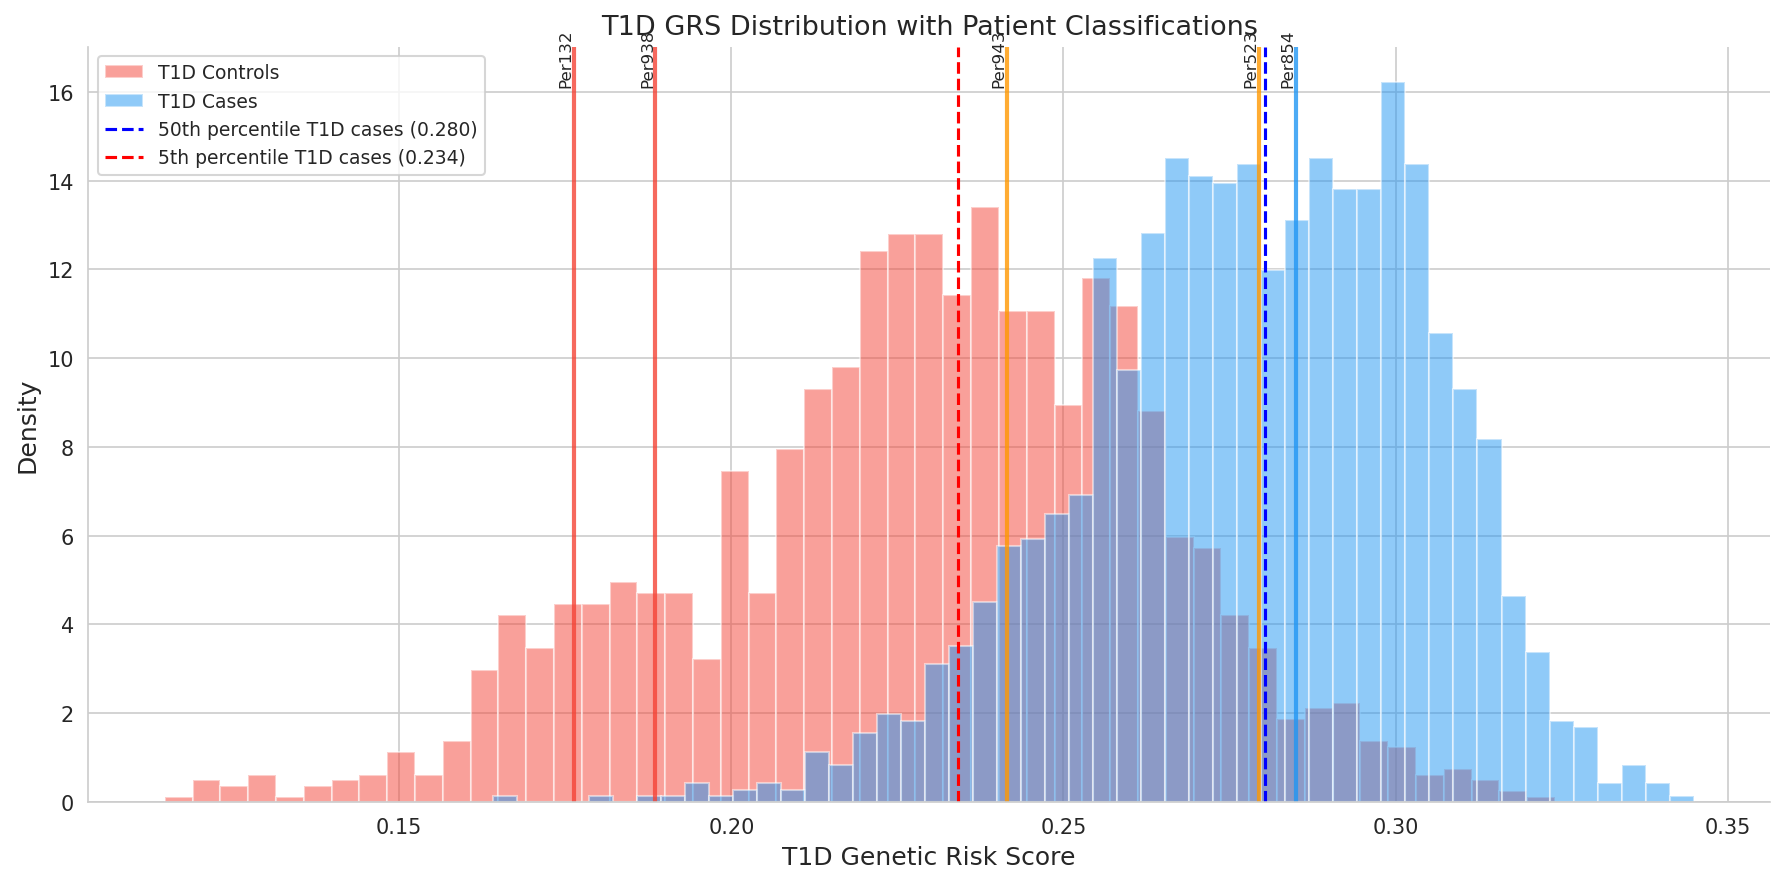

Classification plot saved successfully!


In [69]:
fig, ax = plt.subplots(figsize=(12, 6))

# ── Plot reference distributions ──────────────────────────────────────────────
ax.hist(
    t1d_controls["t1d_grs"],
    bins=50,
    alpha=0.5,
    color="#F44336",
    label="T1D Controls",
    density=True
)
ax.hist(
    t1d_cases["t1d_grs"],
    bins=50,
    alpha=0.5,
    color="#2196F3",
    label="T1D Cases",
    density=True
)

# ── Plot thresholds ───────────────────────────────────────────────────────────
ax.axvline(
    upper_threshold,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label=f"50th percentile T1D cases ({upper_threshold:.3f})"
)
ax.axvline(
    lower_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"5th percentile T1D cases ({lower_threshold:.3f})"
)

# ── Plot patient GRS values ───────────────────────────────────────────────────
colours = {
    "Likely T1D": "#2196F3",
    "Unlikely T1D": "#F44336",
    "Uncertain": "#FF9800"
}

for _, row in grs_df.iterrows():
    ax.axvline(
        row["GRS"],
        color=colours[row["Classification"]],
        linestyle="-",
        linewidth=2,
        alpha=0.8
    )
    ax.text(
        row["GRS"],
        ax.get_ylim()[1] * 0.95,
        row["Patient"],
        rotation=90,
        fontsize=8,
        ha="right"
    )

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xlabel("T1D Genetic Risk Score", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    "T1D GRS Distribution with Patient Classifications",
    fontsize=13
)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(DATA_PATH + "grs_classification.png", dpi=150)
plt.show()

print("Classification plot saved successfully!")

### 6.4 Save Final Classification Results

In [70]:
# ── Save final classification results ────────────────────────────────────────
grs_df.to_csv(
    DATA_PATH + "patient_classifications.txt",
    sep="\t",
    index=False
)

print("Final classifications saved to patient_classifications.txt")
print("\nFinal Patient Classifications:")
print("─" * 60)
for _, row in grs_df.iterrows():
    print(
        f"{row['Patient']:10s} | GRS: {row['GRS']:.6f} | "
        f"{row['Classification']}"
    )

Final classifications saved to patient_classifications.txt

Final Patient Classifications:
────────────────────────────────────────────────────────────
Per132     | GRS: 0.176248 | Unlikely T1D
Per523     | GRS: 0.279364 | Uncertain
Per854     | GRS: 0.284974 | Likely T1D
Per943     | GRS: 0.241421 | Uncertain
Per938     | GRS: 0.188559 | Unlikely T1D
